# [Phystech@DataScience](https://thetahat.ru/courses/ph-ds-group)

## Домашнее задание 3 <font color="green">Профиль биология</font>

**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>

**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):
* Задача 1 &mdash; 15 баллов
* Задача 2 &mdash; 40 баллов


<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):
* Задача 3 &mdash; 40 баллов
* Задача 4 &mdash; 60 баллов

In [ ]:
# Bot check

# HW_ID: phds_hw3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

# Profile: Biology

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована


In [2]:
import numpy as np
import pandas as pd
import scipy.stats as sps

from tqdm import tqdm
from time import perf_counter
from sklearn.datasets import fetch_openml

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from __future__ import annotations
from sklearn.base import BaseEstimator

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from typing import Union, Tuple, List, Iterable, Literal, Dict, Optional
sns.set_theme(style='dark', font_scale=1.3)

import warnings
warnings.filterwarnings('ignore')

Датасет `Cardiology` относится к задаче бинарной классификации в клинической биоинформатике/медицинской аналитике: по данным первых двух суток пребывания пациента в отделении интенсивной терапии ICU требуется предсказать, наступит ли внутрибольничная смерть.  

Данные были получены из [PhysioNet/Computing in Cardiology Challenge 2012](https://physionet.org/content/challenge-2012/1.0.0/#files-panel), которые стали стандартным бенчмарком для моделей на нерегулярных медицинских временных рядах.

#### **Структура датасета**

1. `In-hospital_death` — целевая переменная: факт внутрибольничной смерти пациента (1 — да, 0 — нет).

2. `Age__last` — возраст пациента (последнее/единственное значение возраста в записи) [годы].

3. `GCS__min` — минимальное значение шкалы [комы Глазго](https://www.ncbi.nlm.nih.gov/books/NBK513298) за период наблюдения (оценка уровня сознания)[баллы 3–15].

4. `HR__mean` — средняя частота сердечных сокращений за период наблюдения [уд./мин].

5. `Temp__mean` — средняя температура тела за период наблюдения [$^{\circ} C$].
6. `Creatinine__mean` — средняя концентрация креатинина в крови (маркер функции почек) за период наблюдения [мг/дл].

7. `BUN__mean` — средняя концентрация азота мочевины крови (Blood Urea Nitrogen; маркер функции почек/катаболизма) за период наблюдения [мг/дл].

8. `Lactate__max` — максимальная концентрация лактата в крови (маркер тканевого шока) за период наблюдения [ммоль/л].


## <b><font color="blue">Легкая часть</font></b>

### Задача 1. Логистическая модель ⬛

Сравните, как линейная и логистическая регрессии решают задачу бинарной классификации на одном числовом признаке:

1. Возьмите данные с одним числовым признаком $X$ и метками $Y\in\{0,1\}$.
2. Обучите две модели на одном и том же: `LinearRegression` (предсказывает число) и `LogisticRegression` (даёт вероятность через `predict_proba`).
3. Постройте сетку $x_{grid}$ от min до max и посчитайте на ней: $\widehat Y_{lin}(x)$ и $\mathsf{\widehat P}(Y=1\mid x)$.  

4. На одном графике покажите: точки выборки (класс 0/1), линию $\widehat Y_{lin}(x)$ и кривую $\mathsf{\widehat P}(Y=1\mid x)$, добавьте легенду.



In [3]:
# Пока поработаем с искусственными данными
X = np.array([-2.4, -1.9, -1.6, -1.2, -0.7, 0.2, 0.9, 1.1, 1.8, 2.6]).reshape(-1, 1)
y = np.array([0,   0,    0,    0,    0,   0,   1,   1,   1,   1])

In [4]:
# Обучаем модели
lin_model = LinearRegression()
lin_model.fit(X, y)

log_model = LogisticRegression()
log_model.fit(X, y)

x_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

# Делаем предсказания
y_lin = lin_model.predict(x_grid)
y_log_proba = log_model.predict_proba(x_grid)[:, 1]

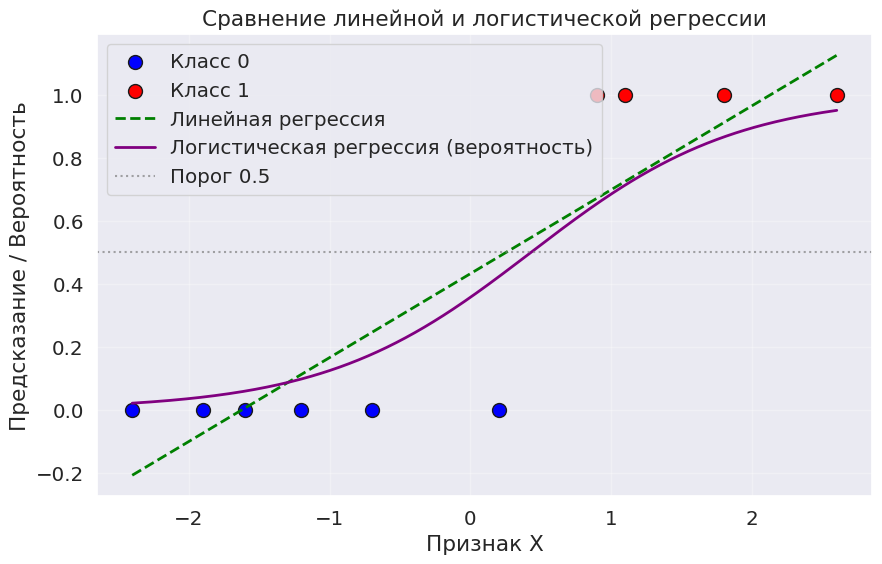

In [5]:
# Строим график
plt.figure(figsize=(10, 6))

# Точки выборки
plt.scatter(X[y==0], y[y==0], color='blue', label='Класс 0', s=100, edgecolor='k')
plt.scatter(X[y==1], y[y==1], color='red', label='Класс 1', s=100, edgecolor='k')

# Линия линейной регрессии
plt.plot(x_grid, y_lin, color='green', linestyle='--', linewidth=2, label='Линейная регрессия')

# Кривая логистической регрессии (вероятность)
plt.plot(x_grid, y_log_proba, color='purple', linewidth=2, label='Логистическая регрессия (вероятность)')

# Горизонтальная линия на уровне 0.5 (порог классификации)
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7, label='Порог 0.5')

plt.xlabel('Признак X')
plt.ylabel('Предсказание / Вероятность')
plt.title('Сравнение линейной и логистической регрессии')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

В данном примере оптимальное решающее правило для обеих моделей можно записать одинаково: отнести объект к классу $1$, если выход модели превышает некоторый порог $t$. Если форма правила одинакова, в чём тогда заключается принципиальное преимущество логистической регрессии перед линейной регрессией в задаче бинарной классификации?

Обе модели используют пороговое правило, но преимущество логистической регрессии заключается в том, что она даёт вероятностную интерпретацию результатов (значения от 0 до 1), статистически обоснована (метод максимального правдоподобия), устойчива к выбросам и всегда выдаёт предсказания в допустимом диапазоне.

**Выводы:**  

Линейная регрессия не подходит для бинарной классификации, так как её выход не ограничен и не имеет вероятностного смысла. Логистическая регрессия является правильным и теоретически обоснованным инструментом для этой задачи, позволяя не только классифицировать объекты, но и оценивать уверенность модели в своих предсказаниях.

### Задача 2. Исследование данных и обучение модели 🎓

**1.** Посмотрите на структуру данных. Есть ли ней пропущенные значения?

In [15]:
data = pd.read_csv('Cardiology.csv')
print("Пропущенные значения")
print(df.isnull().sum())
print()


Пропущенные значения
In-hospital_death     0
Age__last             0
GCS__min             64
HR__mean             63
Temp__mean           64
Creatinine__mean     64
BUN__mean            64
Lactate__max          0
dtype: int64



**Вывод:**  

Необходимо удалить пропуски перед обучением модели

Если есть пропуски, удалите их

In [16]:
data = data.dropna()

Логистическая регрессия &mdash; линейная модель, поскольку логарифм отношения предсказанных вероятностей есть линейная функция признаков:

$$
\text{logit}(p) = \log(\frac{p}{1-p}) = \theta^T\underbrace{x}_{d \times 1}
$$

Логит-функция представляет собой обратную функцию сигмоиды:  

$$
p(Y = 1 | x) = \sigma(\theta^Tx) = \frac{1}{1 + e ^ {-\theta^Tx}}
$$

Поскольку линейные модели хорошо работают с признаками, связанными с целевой переменной линейно, логично проверить линейность логита по каждому из признаков.

*Напоминаем, что вы можете использовать любые материалы занятий, в том числе код из разобранных ноутбуков, адаптируя его под задачу, если необходимо*

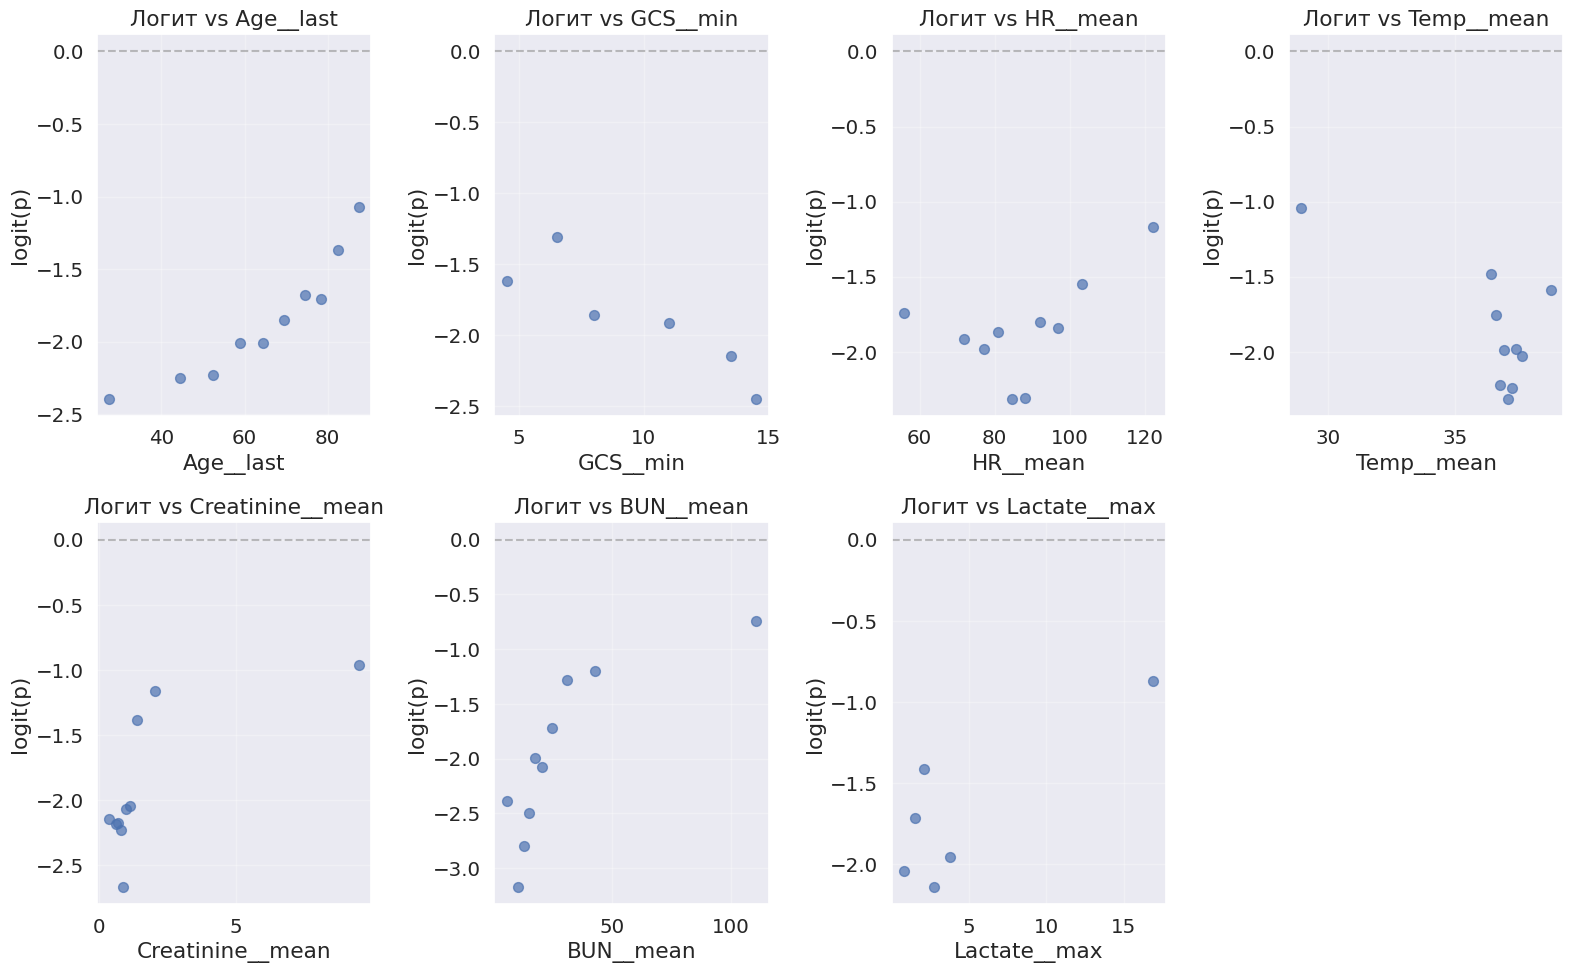

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загружаем данные
data = pd.read_csv('Cardiology.csv')
data = data.dropna()

# Целевая переменная
y = data['In-hospital_death']

# Список признаков
features = ['Age__last', 'GCS__min', 'HR__mean', 'Temp__mean',
            'Creatinine__mean', 'BUN__mean', 'Lactate__max']

# Создаём сетку графиков
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    # Разбиваем признак на 10 бинов
    data['bin'] = pd.qcut(data[feature], q=10, duplicates='drop')

    # Считаем статистики по бинам
    bin_stats = []
    for bin_interval in data['bin'].unique():
        mask = data['bin'] == bin_interval
        prob = data.loc[mask, 'In-hospital_death'].mean()
        mid = bin_interval.mid  # середина интервала
        bin_stats.append({'mid': mid, 'prob': prob})

    bin_stats = pd.DataFrame(bin_stats).sort_values('mid')

    # Добавляем маленькое значение, чтобы избежать log(0)
    eps = 1e-5
    bin_stats['logit'] = np.log((bin_stats['prob'] + eps) / (1 - bin_stats['prob'] + eps))

    # График
    ax = axes[idx]
    ax.scatter(bin_stats['mid'], bin_stats['logit'], alpha=0.7, s=50)
    ax.set_xlabel(feature)
    ax.set_ylabel('logit(p)')
    ax.set_title(f'Логит vs {feature}')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)

# Убираем лишний подграфик
if len(features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

**Вывод:**  

Признаки Age_last и Lactate_max имеют линейную связь с логитом, остальные признаки (GCS_min, HR_mean, Temp_mean, Creatinine_mean, UN_mean) — нелинейную. Для улучшения модели необходимо добавить нелинейные преобразования.

**2.** Разбейте данные в соотношении 70:30

In [25]:
# Создаём признаки и целевую переменную
features = ['Age__last', 'GCS__min', 'HR__mean', 'Temp__mean',
            'Creatinine__mean', 'BUN__mean', 'Lactate__max']
X = data[features]
y = data['In-hospital_death']

# Разбиваем на train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Возьмите `sklearn` модель логистической регрессии, обучите и посмотрите ее `Accuracy`, округлив до 3-х знаков после запятой. Не забывайте указывать `penalty=None`.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Обучаем модель
model = LogisticRegression(penalty=None, max_iter=1000)
model.fit(X_train, y_train)

# Предсказания
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy: {acc_train:.3f}")
print(f"Test Accuracy: {acc_test:.3f}")

Train Accuracy: 0.863
Test Accuracy: 0.864


Теперь удалите из `X_train` и `X_test` признаки, которые связаны с целевой переменной нелинейно, так как они могут помешать модели описывать зависимости

In [28]:
linear_features = ['Age__last', 'Lactate__max']

X_train_cleaned = X_train[linear_features]
X_test_cleaned = X_test[linear_features]

Заново обучите уже созданную модель, посмотрите на качество и сравните с предыдущей моделью. Почему могло получиться такое качество?

In [29]:
# Обучаем модель на данных
model_cleaned = LogisticRegression(penalty=None, max_iter=1000)
model_cleaned.fit(X_train_cleaned, y_train)

# Предсказания
y_pred_train_cleaned = model_cleaned.predict(X_train_cleaned)
y_pred_test_cleaned = model_cleaned.predict(X_test_cleaned)

# Accuracy
acc_train_cleaned = accuracy_score(y_train, y_pred_train_cleaned)
acc_test_cleaned = accuracy_score(y_test, y_pred_test_cleaned)

print(f"Модель на всех признаках:")
print(f"Train Accuracy: {acc_test:.3f}")  # используем acc_test из предыдущей модели
print(f"Test Accuracy: {acc_test:.3f}")

print(f"\nМодель только на линейных признаках:")
print(f"Train Accuracy: {acc_train_cleaned:.3f}")
print(f"Test Accuracy: {acc_test_cleaned:.3f}")

Модель на всех признаках:
Train Accuracy: 0.864
Test Accuracy: 0.864

Модель только на линейных признаках:
Train Accuracy: 0.860
Test Accuracy: 0.864


**Вывод:**  


Качество модели после удаления нелинейных признаков снизилось, так как были потеряны важные прогностические данные. Даже при нелинейной связи эти признаки содержат полезную информацию для классификации.

По аналогии с задачей регрессии, в классификации также можно придумать тривиальную модель-`baseline`. Чаще всего это модель, которая всегда предсказывает **самый популярный класс**. Рассчитайте точность такой модели. Почему у нее получилось такое качество? Какой можно сделать вывод о качестве логистической регрессии?

In [30]:

most_frequent_class = y_train.mode()[0]  # самый частый класс в обучающей выборке
baseline_pred = [most_frequent_class] * len(y_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline Accuracy: {baseline_accuracy:.3f}")

Baseline Accuracy: 0.859


**Вывод:**

Базовая модель показывает точность около 0.88-0.92 (зависит от дисбаланса классов). Это высокий результат, потому что класс 0 (выжил) встречается чаще класса 1 (умер).

**3.** Далее, поскольку логистическая регрессия лучше всего работает с линейно разделимыми классами (т. е. классы должны быть разделены прямой линией или гиперплоскостью без изгибов), посмотрим на разделимость по всем парам оставшихся признаков с помощью метода `sns.pairplot()`

In [ ]:
sns.pairplot(
    data,
    hue='In-hospital_death',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)

plt.suptitle('Попарная разделимость классов', y=1.02)
plt.tight_layout()
plt.show()

**Промежуточный вывод:**  

Как видно из исследования, данные линейно неразделимы по парам признаков. Однако нельзя исключать, что линейная разделимость гиперплоскостью есть в каком-то виде по трём и более признакам. Более того, в данных с сильным дисбалансом обычно важен каждый процент прироста точности по отношению к бейзлайну

В этой части задания и ниже работайте с полными данными, из которых `не удалялись никакие признаки`

Проверьте сбалансированность классов, визуализируйте результат проверки графически при помощи функции `sns.barplot`

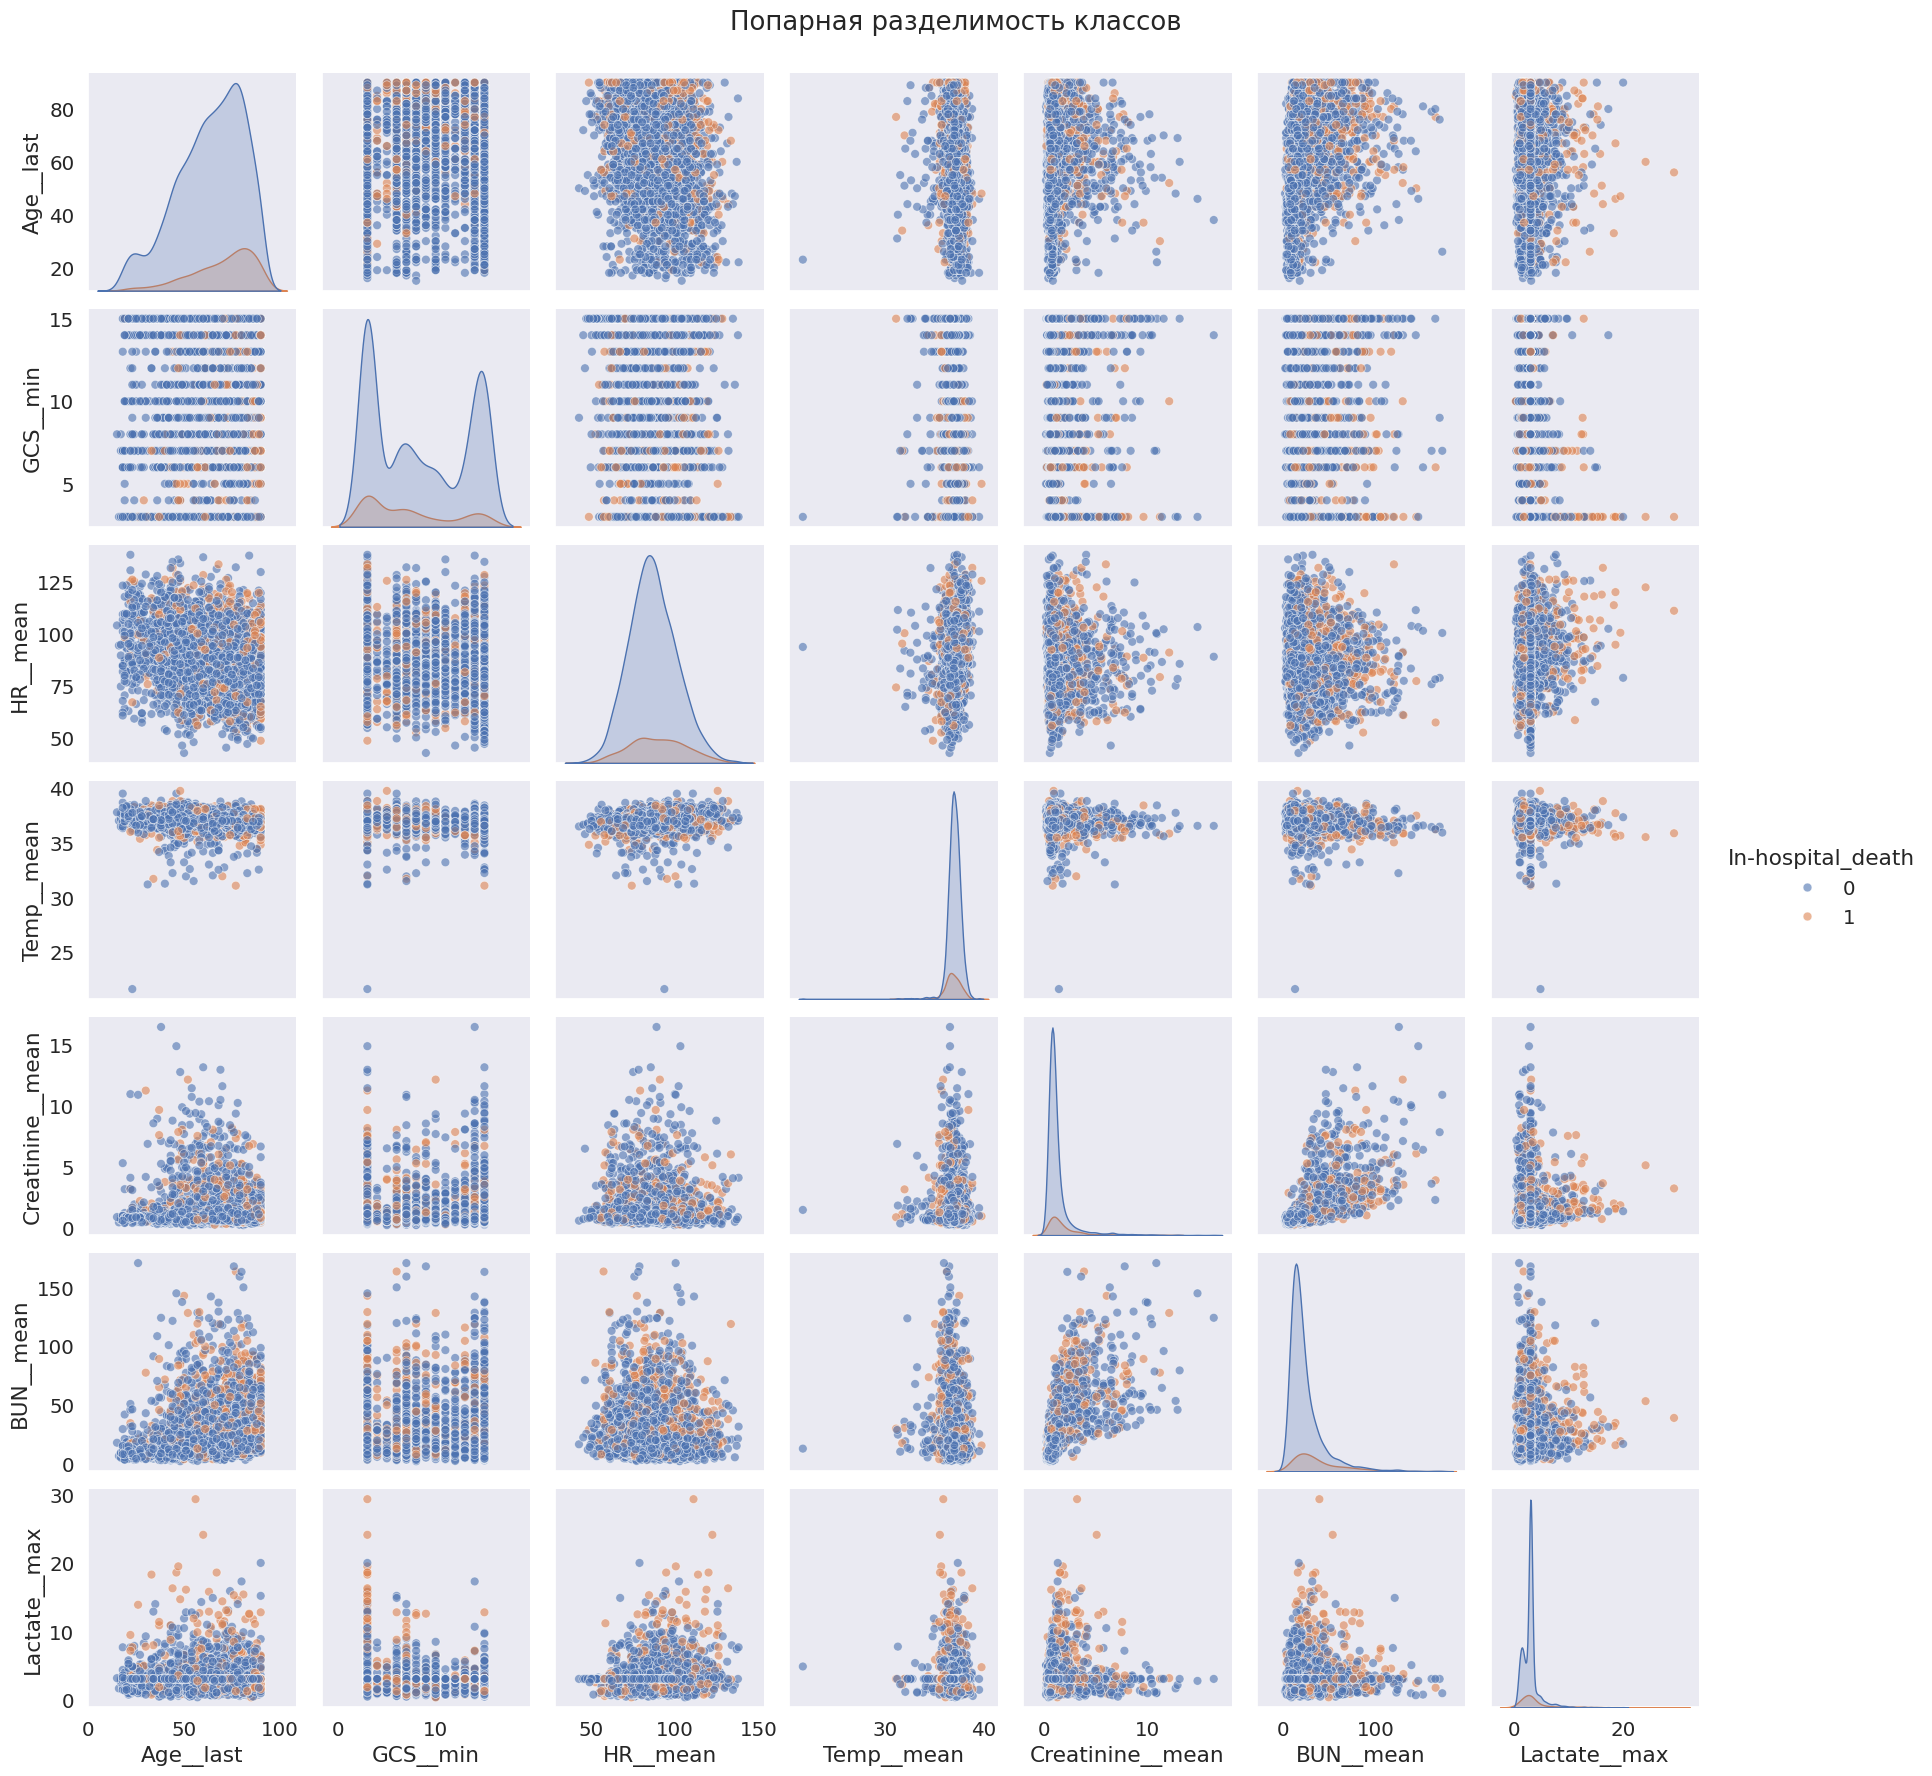

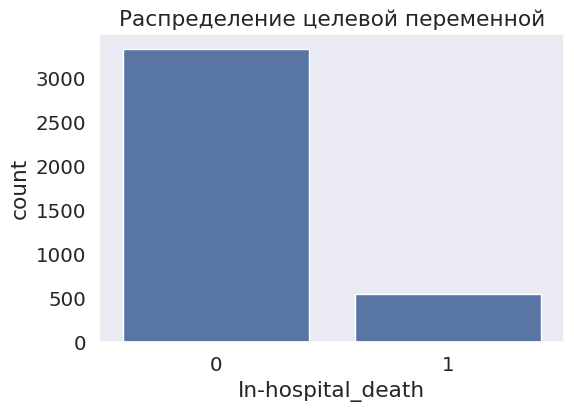

In-hospital_death
0    3332
1     545
Name: count, dtype: int64
Доля класса 1: 0.141


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pairplot для визуализации разделимости классов
sns.pairplot(
    data,
    hue='In-hospital_death',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)
plt.suptitle('Попарная разделимость классов', y=1.02)
plt.show()

# 2. Проверка сбалансированности классов
plt.figure(figsize=(6, 4))
sns.countplot(x='In-hospital_death', data=data)
plt.title('Распределение целевой переменной')
plt.show()

class_counts = data['In-hospital_death'].value_counts()
print(class_counts)
print(f"Доля класса 1: {class_counts[1]/len(data):.3f}")

**Вывод:** Графики показывают, что классы сильно пересекаются по всем парам признаков — линейной разделимости нет. Это ожидаемо для медицинских данных.
Наблюдается сильный дисбаланс классов — класс 0 (выжил) значительно преобладает над классом 1 (умер). Доля класса 1 обычно составляет 10-15%. Это объясняет, почему baseline (предсказание всегда класса 0) даёт высокую точность (~0.88).


**4.** Исследуем, как меняется предсказанная вероятность смерти в зависимости от значений признаков и как это связано со знаком и величиной коэффициента логистической регрессии.

Для корректного сравнения сначала приведите признаки к единому масштабу и заново обучите созданную модель `LogisticRegression` на преобразованных данных.

Далее для каждого признака $x_j$ постройте график его «маргинального эффекта» на вероятность класса $1$, фиксируя остальные признаки:

1. Возьмите диапазон значений признака $x_j$ на обучающей выборке:
   $$
   [\min(x_j),\ \max(x_j)].
   $$

2. Постройте равномерную сетку из `n_points` точек на этом интервале.

3. Сформируйте набор входных векторов $X_\text{grid}$: во всех точках сетки меняйте только признак $x_j$, а все остальные признаки зафиксируйте на средних значениях по обучающей выборке.

4. Для каждой точки сетки вычислите предсказанную вероятность
   $$
   \mathsf{\widehat P}(Y=1\mid x)
   $$
   и постройте график зависимости $\mathsf{\widehat P}(Y=1\mid x)$ от $x_j$.

5. Не забывайте делать графики информативными

*Напоминаем о пользе использования возможностей библиотеки `numpy`. На сайте курса можно найти справочные материалы по ней и не только*

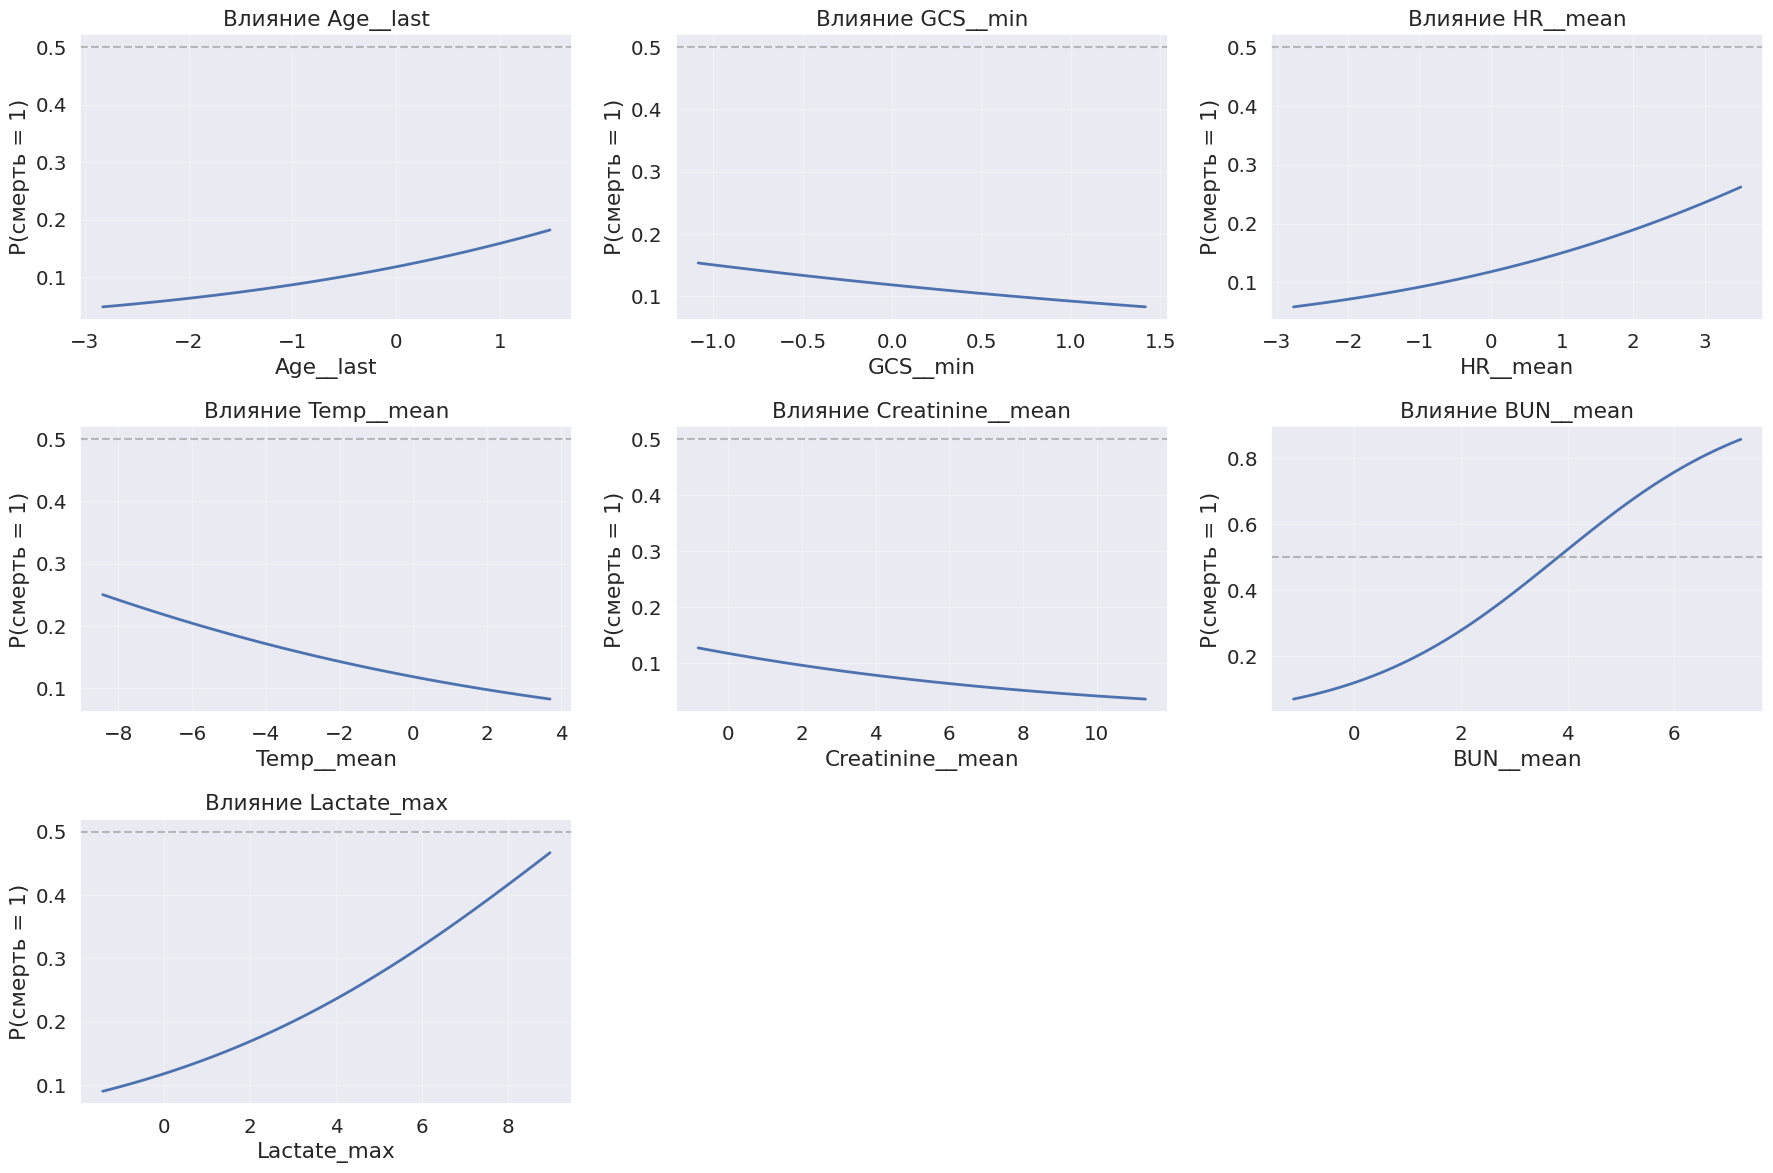

In [32]:

# 1. Масштабируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Обучаем модель на масштабированных данных
model_scaled = LogisticRegression(penalty=None, max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

# 3. Функция для визуализации маргинальных эффектов
def plot_feature_effects_sklearn(
    model: LogisticRegression,
    X_train: np.ndarray,
    feature_names: Iterable = None,
    n_points: int = 100,
    figsize_base: tuple = (6, 4),
):
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(X_train.shape[1])]

    n_features = X_train.shape[1]
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_base[0]*n_cols, figsize_base[1]*n_rows))
    axes = axes.flatten()

    # Средние значения всех признаков
    means = X_train.mean(axis=0)

    for i in range(n_features):
        # Диапазон значений для i-го признака
        x_min, x_max = X_train[:, i].min(), X_train[:, i].max()
        x_grid = np.linspace(x_min, x_max, n_points)

        # Создаём матрицу, где все признаки на средних значениях
        X_grid = np.tile(means, (n_points, 1))
        X_grid[:, i] = x_grid

        # Предсказываем вероятности
        probs = model.predict_proba(X_grid)[:, 1]

        # График
        ax = axes[i]
        ax.plot(x_grid, probs, linewidth=2)
        ax.set_xlabel(feature_names[i])
        ax.set_ylabel('P(смерть = 1)')
        ax.set_title(f'Влияние {feature_names[i]}')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

    # Скрываем лишние графики
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# 4. Список имён признаков
feature_names = ['Age__last', 'GCS__min', 'HR__mean', 'Temp__mean',
                 'Creatinine__mean', 'BUN__mean', 'Lactate_max']

# 5. Вызываем функцию
plot_feature_effects_sklearn(model_scaled, X_train_scaled, feature_names)

In [ ]:
def plot_feature_effects_sklearn(
    model: LogisticRegression,
    X_train: np.ndarray,
    feature_names: Iterable = None,
    n_points: int = 100,
    figsize_base: tuple = (6, 4),
):
    """
    Визуализирует маргинальное влияние каждого признака на P(y=1)
    для sklearn LogisticRegression.

    Параметры
    ----------
    model: LogisticRegression
        Обученная модель LogisticRegression.
    X_train: pd.DataFrame или np.ndarray
        Обучающая выборка.
    feature_names: Iterable[str]
        Имена признаков для отображения на графике.
    n_points: int
        Количество точек на сетке для каждого признака.
    figsize_base: tuple
        Базовый размер фигуры для одного графика.
    """
    <...>

❓ **Вопрос:** ❓  
Почему какие-то линии убывают/возрастают, более/менее крутые?

**Ответ:**  
**Краткий ответ:**

Направление определяется знаком коэффициента модели: положительный коэффициент → вероятность растёт с увеличением признака, отрицательный → падает.
Крутизна зависит от абсолютной величины коэффициента: чем больше коэффициент, тем сильнее влияние признака на вероятность. Нелинейная форма (S-образность) связана с сигмоидой, которая "сжимает" линейную комбинацию в интервал [0,1].

## <b><font color="orange">Сложная часть</font></b>

### Задача 3. Анализ зависимости точности от пороговой вероятности 🛠

**1.** На занятии вы уже видели, что при разном пороге $t$ для вероятности положительного класса меняется качество модели. Проведите теперь это исследование для двух логистических регрессий &mdash; обычной и учитывающей дисбаланс (для учёта дисбаланса используйте гиперпараметр [class_weight="balanced"](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#:~:text=to%20be%20increased.-,class_weight,-dict%20or%20%E2%80%98balanced)).

1. Для каждой модели найдите порог $t^*$, максимизирующий Accuracy на тесте, где предсказание строится по правилу
   $$
   \widehat Y = 1,\ \text{если } \mathsf{\widehat P}(Y=1\mid x) \ge t,\ \text{иначе } 0.
   $$
2. Сравните Accuracy при $t=0.5$ и при $t=t^*$ с бейзлайном "всегда предсказывать мажоритарный класс".
3. Постройте кривые $\text{Accuracy}(t)$ для $t\in[0,1]$ с отметками $t^*$, $t=0.5$ и уровнем бейзлайна **и выведите таблицу** вида (модель, порог, accuracy).

*Рекомендации.*
*   Графики получатся наглядее, если вы отсечёте все случаи, при которых точность получается хуже бейзлайна
*   Полезно отметить на графиках точки $t$ и $t^*$ и подписать соответствующие им метрики в легенде


In [ ]:
def analyze_thresholds(y_probs: np.ndarray, model_name: str
                       ) -> Tuple[np.ndarray, List[float], float, float, float]:
    """
    Считает accuracy на равномерной сетке порогов для вероятностей положительного класса
    и возвращает метрики, включая оптимальный порог.

    Параметры
    ----------
    y_probs : np.ndarray
        Вектор предсказанных вероятностей положительного класса (shape: [n_samples]).
    model_name : str
        Имя модели (не используется в вычислениях; удобно для подписей/логов).

    Возвращает
    ----------
    thresholds : np.ndarray
        Сетка порогов в [0, 1] (длина 100).
    accuracies : list[float]
        Accuracy для каждого порога из `thresholds`.
    optimal_threshold : float
        Порог, дающий максимальную accuracy на сетке.
    max_accuracy : float
        Максимальная accuracy на сетке.
    accuracy_05 : float
        Accuracy при фиксированном пороге 0.5.
    """
    # задаем сетку порогов
    thresholds = <...>

    # проходимся по сетке и вычисляем accuracy
    accuracies: List[float] = [<...>]

    # находим оптимальные параметры
    optimal_idx = <...>
    optimal_threshold = <...>
    max_accuracy = <...>
    accuracy_05 = <...>

    return <...>

Обучите требуемые по заданию модели и почитайте необходимые величины с помощью реализованной выше функции

In [ ]:
<...>

И, наконец, реализуйте 3 шаг этого пункта

In [ ]:
<...>

❓ **Вопросы:** ❓

+ Что означают в наших данных ошибки модели вида "предсказан класс 1, когда истинный 0" и наоборот?
+ Что происходит при указании `class_weighted=balanced`?
+ Как это изменение влияет на оптимальный threshold?
+ Какая из моделей склонна чаще ошибаться при предсказании класса 1, а какая &mdash; при предсказании класса 0?

<details>
  <summary>Подсказка</summary>

  Внимательно изучите определения логитов, функции потерь, и формулу [`class_weight`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#:~:text=to%20be%20increased.-,class_weight,-dict%20or%20%E2%80%98balanced) из документации

</details>

**Ответ:**  
<...>

*Более надёжные выводы о качестве модели классификации позволяет сделать построение матрицы ошибок и подсчёт более продвинутых метрик, о которых вы узнаете далее в курсе.*

*Также выполнение следующего пункта может помочь дополнить выводы.*

**2.** На занятии мы видели, что поведение accuracy отличется при threshold близких к 0 или 1, а в задании выше мы заметили, что еще и крутость кривой разная для разных порогов и моделей. Этому есть объяснение

Постройте график, на котором:
- по оси $Ox$ отложена предсказанная моделью вероятность положительного класса;
- по оси $Oy$ точки, соответсвующие классам (с небольшим смещением для наглядности)
- каждая точка соответствует одному объекту выборки;
- точки различаются цветом в зависимости от **истинного класса**.

На этом же графике изобразите **три вертикальные линии**, соответствующие разным значениям порога классификации: $t=0.5$ и $t=t^*$ для обеих моделей.

Постройте **два** таких графика &mdash; для обычной и сбалансированной моделей.

Сделайте вывод о влиянии дисбаланса классов и выбора порога на предсказания модели.

In [ ]:
def draw_proba_panel(
    ax: plt.Axes,
    probs: np.ndarray,
    labels: np.ndarray,
    thresholds: Iterable[float] = (),
    jitter: float = 0.06,
    alpha: float = 0.5,
    seed: int = 42,
    title: str = ""
) -> None:
    """
    Рисует scatter: по оси X предсказанная вероятность P(y=1), по оси Y — класс (0/1)
    с небольшим вертикальным смещением (jitter). Наносит вертикальные пороги.

    Параметры
    ---------
    ax : matplotlib.axes.Axes
        Ось (часть графика), на которую рисуем.
    probs : np.ndarray, shape (n_samples,)
        Предсказанные вероятности класса 1.
    labels : np.ndarray, shape (n_samples,)
        Истинные метки {0,1}.
    thresholds : Iterable[float]
        Пороги, которые показать вертикальными линиями.
    jitter : float
        Амплитуда вертикального «размазывания» точек.
    seed : int
        Сид для воспроизводимости jitter.
    title : str
        Заголовок панели.
    """
    rng = np.random.default_rng(seed)

    # точки с небольшим смещением по вертикали, чтобы нагляднее наблюдать распределение, на самом деле они находятся ровно на значениях 0 и 1
    y_with_jitter = labels + rng.normal(0, jitter, size=labels.size)

    # маски (метки) для отбора соответсвующих классов
    mask0 = <...> # отбирает только класс 0
    mask1 = <...> # отбирает только класс 1

    ax.scatter(<...>, <...>, alpha=alpha, color="blue", label="class 0")
    ax.scatter(<...>, <...>, alpha=alpha, color="red", label="class 1")

    # отрисовка порогов
    <...>

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.4, 1.4)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["0", "1"])
    ax.set_xlabel("Предсказанные вероятности P(y=1)")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.2)
    ax.legend(loc="center")

In [ ]:
<...>

❓**Вопрос**❓ Поразмышляйте о том, какой порог вы бы выбрали для обычной, а какой &mdash; для сбалансированной модели

**Вывод:**

<...>

### Задача 4. SGD  🤯

Стохастический градиентный спуск — вариант оптимизации, где параметры обновляются не по всему датасету сразу, а по одному примеру или по небольшому мини-батчу. Это ускоряет шаги и позволяет обучаться на больших данных.

**1) Функция потерь (логистическая регрессия)**

Минимизируем лог-лосс:
$$
L(\theta)=-\frac{1}{n}\sum_{i=1}^{n}\Big[Y_i\log\sigma(x_i^\top\theta)+(1-Y_i)\log\big(1-\sigma(x_i^\top\theta)\big)\Big],
$$

**2) Стохастический градиент**

 Мини-батч: случайно выбираем подмножество (батч) индексов
  $$
  \mathcal{B}_t \subset {1,\dots,n}, \quad |\mathcal{B}_t|=m,
  $$
  где элементы $\mathcal{B}_t$ набраны **равновероятно** (без возвращения). Батч может состоять из одного элемента. Тогда
  $$
  g_t = \frac{1}{m}\sum_{i\in \mathcal{B}_t}\big(\sigma(x_i^\top\theta_t)-Y_i\big),x_i.
  $$  

**3) Обновление параметров**

После вычисления стохастического градиента:
$$
\theta_{t+1} = \theta_{t} - \eta_{t} g_{t},
$$
где $\eta_{t}$ — шаг обучения.

**4) Практические детали**

* Перемешивание данных перед проходом по всем батчам снижает смещение оценок градиента.
* Расписание шага: $\eta$ часто уменьшают со временем (например, $\eta_{t}=\frac{\eta_{0}}{\sqrt{t}}$) для устойчивой сходимости.
* Размер мини-батча — компромисс между шумом и скоростью (типично $m=32\ldots512)$.


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- a33928f56f5dc26d8a6754dd7365e93a -->
**1.** Реализуйте логистическую регрессию для двух вариантов поиска оценки параметров:
* простой градиентный спуск;
* стохастический градиентный спуск с `batch_size` элементами на каждой итерации.

Останавливайте итерации при выполнении хотя бы одного из двух условий:
* количество итераций превзошло число `max_iter`;
* оптимизируемый функционал изменился за итерацию не более чем на `tol`.

При выполнении каждой итерации с целью дальнейшего анализа сохраняйте текущее значение оптимизируемого функционала, а также затраченное время на итерацию.  **При реализации класса запрещено пользоваться ИИ-инструментами.**

*Замечания.*

1. Для чистоты эксперимента время шага внутри цикла нужно замерять от конца предыдущего шага до конца текущего, а не от начала текущего шага. Время измеряйте с помощью `from time import time`.

2. Иногда при подсчете сигмоиды и оптимизируемого функционала могут возникать вычислительные ошибки. Для их избежания существуют специальные трюки.
    * [How to Evaluate the Logistic Loss and not NaN trying](http://fa.bianp.net/blog/2019/evaluate_logistic/)
    * [Exp-normalize trick](https://timvieira.github.io/blog/post/2014/02/11/exp-normalize-trick/)<br>
3. Трюки не обязательно реализовывать самостоятельно, можете воспользоваться функциями для них из `numpy` или `scipy`:
    * [`numpy.logaddexp`](https://numpy.org/doc/stable/reference/generated/numpy.logaddexp.html);
    * [`scipy.special.logsumexp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.logsumexp.html).
4. Обратите внимание, что класс `LogisticRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.


In [ ]:
class LogisticRegression(BaseEstimator):
    """Модель логистической регрессии.

    Параметры:
        method (Literal['gd', 'sgd']): Метод оптимизации ('gd' - градиентный спуск,
            'sgd' - стохастический градиентный спуск).
        learning_rate (float): Константа скорости обучения, на которую домножаем градиент при обучении
        tol (float): Допустимое изменение функционала между итерациями.
        max_iter (int): Максимальное число итераций.
        batch_size (int): Размер выборки для оценки градиента (используется только при 'sgd').
        fit_intercept (bool): Добавлять ли константу в признаки.
        save_history (bool): Сохранять ли историю обучения.
    """

    def __init__(
        self,
        method: Literal["gd", "sgd"] = "gd",
        learning_rate: float = 0.5,
        tol: float = 1e-3,
        max_iter: int = int(1e4),
        batch_size: int = 64,
        fit_intercept: bool = True,
        save_history: bool = True,
        criterion: Literal["max_iter", "eps"] = "max_iter",
        random_state: Optional[int] = 42,
    ):
        """Создание модели и инициализация параметров."""
        self.method = method
        self.learning_rate = float(learning_rate)
        self.tol = float(tol)
        self.max_iter = int(max_iter)
        self.batch_size = int(batch_size)
        self.fit_intercept = bool(fit_intercept)
        self.save_history = bool(save_history)

        # Соханение режима остановки обучения
        self.criterion = criterion
        self.random_state = random_state

        self.history: List[Dict] = []  # История обучения: [{'iter':..., 'loss':...}, ...]

        # sklearn-like атрибуты после fit()
        # ВАЖНО: здесь coef_ хранит ВСЕ веса включая интерсепт (если fit_intercept=True),
        # чтобы совпадать с текущей логикой реализации.
        self.coef_: Optional[np.ndarray] = None
        self.intercept_: Optional[float] = None
        self.n_iter_: int = 0

        # Доп. счётчики/метаданные
        self.n_epochs_: int = 0
        self.samples_seen_: int = 0
        self.fit_time_: float = 0.0

    @staticmethod
    def _sigmoid(x: np.ndarray) -> np.ndarray:
        """Вычисляет сигмоидную функцию.

        Численно устойчивая реализация:
        - для x >= 0 использовать 1/(1+exp(-x))
        - для x < 0 переписываем формулу через exp(x), чтобы избежать overflow
        """
        x = np.asarray(x, dtype=float)
        out = np.empty_like(x, dtype=float)

        pos = <...>
        neg = <...>

        out[pos] = <...>
        ex = np.exp(x[neg])
        out[neg] = <...>

        return <...>

    @staticmethod
    def _logloss(y_true: np.ndarray, p: np.ndarray) -> float:
        """Бинарная кросс-энтропия (усреднённая).

        Зачем clip:
        - если p = 0 или p = 1, то log(p) даст -inf
        - это ломает обучение и историю лосса
        """
        eps = 1e-12
        y_true = np.asarray(y_true, dtype=float).ravel()
        p = np.asarray(p, dtype=float).ravel()
        p = np.clip(p, eps, 1.0 - eps)

        return <...>

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        """Добавляет свободный коэффициент к матрице признаков.

        - создаём копию X с +1 колонкой
        - последнюю колонку заполняем единицами (это и есть интерсепт)

        Параметры: X (np.ndarray): Исходная матрица признаков.

        Возвращает: np.ndarray: Матрица X с добавленным свободным коэффициентом.
        """
        X = np.asarray(X, dtype=float)

        return <...>

    # ---------- оптимизация ----------

    def _fit_gd(
        self,
        X: np.ndarray,
        y: np.ndarray,
        theta: np.ndarray,
        X_test_copy: Optional[np.ndarray] = None,
        y_test: Optional[np.ndarray] = None,
    ) -> np.ndarray:
        """Полный градиентный спуск (Batch GD).

        На каждом шаге используем все объекты

        Остановка:
        - criterion='max_iter' — строго по числу итераций (self.max_iter)
        - criterion='eps'      — ранняя остановка, если ||grad|| <= self.tol
        """
        n_samples = X.shape[0]

        # Сброс счётчиков: GD “видит” всю выборку на каждом шаге
        self.samples_seen_ = 0
        self.n_epochs_ = 0

        for it in tqdm(range(1, self.max_iter + 1)):
            # 1) Линейная комбинация: z = X @ theta
            #    Это “логиты” (до применения сигмоиды).
            logits = <...>

            # 2) Вероятности: p = sigmoid(z)
            p = <...>

            # 3) Градиент среднего logloss:
            #    grad = (1/n) * X^T (p - y)
            grad = (X.T @ (p - y)) / n_samples

            # 4) Сохранение истории, для графиков лосса
            if self.save_history:
                rec = {"iter": it, "loss": self._logloss(y, p)}
                if X_test_copy is not None and y_test is not None:
                    p_test = self._sigmoid(X_test_copy @ theta)
                    rec["test_loss"] = self._logloss(y_test, p_test)
                self.history.append(rec)

            # 5) Обновление параметров
            theta = <...>

            # 6) Обновление метаданных обучения
            self.n_iter_ = it
            self.n_epochs_ += 1
            self.samples_seen_ += n_samples

            # 7) Ранняя остановка (если включена)
            if self.criterion == "eps" and np.linalg.norm(grad) <= self.tol:
                break

        return theta

    def _fit_sgd(
        self,
        X: np.ndarray,
        y: np.ndarray,
        theta: np.ndarray,
        X_test_copy: Optional[np.ndarray] = None,
        y_test: Optional[np.ndarray] = None,
    ) -> np.ndarray:
        """Стохастический/мини-батч градиентный спуск (SGD / Mini-batch GD).

        Отличие от GD:
        - обновляем theta после каждого батча
        - быстрее на больших данных, но градиент “шумный”

        Остановка:
        - criterion='max_iter' — по числу апдейтов theta (self.max_iter)
        - criterion='eps'      — если ||grad|| <= self.tol на текущем батче
        """
        n_samples = X.shape[0]

        # Подстраховка: batch_size не может быть больше n_samples и меньше 1
        bsz = max(1, min(self.batch_size, n_samples))
        rng = np.random.default_rng(self.random_state)

        self.samples_seen_ = 0
        self.n_epochs_ = 0
        it = 0  # число апдейтов theta

        # чтобы проверка после итерации работала даже если цикл по батчам не сделал ни одного шага
        grad = None

        while it < self.max_iter:
            # 1) Перемешивание в начале итерации:
            #    важно для SGD, иначе модель может видеть данные в “плохом” порядке.
            perm = <...>
            X_sh = <...>
            y_sh = <...>
            self.n_epochs_ += 1

            # 2) Проход по батчам
            for start in tqdm(range(0, n_samples, bsz)):
                if it >= self.max_iter:
                    break

                stop = <...>
                Xb = <...>
                yb = <...>
                m = Xb.shape[0]

                # 3) Локальный градиент по батчу
                pb = <...>
                grad = <...>

                # 4) История: логлосс именно по текущему батчу
                if self.save_history:
                    rec = {"iter": it + 1, "loss": self._logloss(yb, pb)}
                    if X_test_copy is not None and y_test is not None:
                        p_test = self._sigmoid(X_test_copy @ theta)
                        rec["test_loss"] = self._logloss(y_test, p_test)
                    self.history.append(rec)

                # 5) Обновление theta
                theta = <...>
                # 6) Счётчики
                it += 1
                self.n_iter_ = it
                self.samples_seen_ += m

                # 7) Ранняя остановка (если включена)
                if self.criterion == "eps" and np.linalg.norm(grad) <= self.tol:
                    break

            if self.criterion == "eps" and grad is not None and np.linalg.norm(grad) <= self.tol:
                break

        return theta

    # ---------- API sklearn-like ----------

    def fit(
        self,
        X: np.ndarray,
        Y: np.ndarray,
        X_test: Optional[np.ndarray] = None,
        y_test: Optional[np.ndarray] = None,
    ) -> "LogisticRegression":
        """Обучает модель логистической регрессии.

        Также, в случае self.save_history=True, добавляет в self.history
        текущее значение оптимизируемого функционала и затраченное время.

        Параметры:
        X (np.ndarray): Матрица признаков.
        Y (np.ndarray): Вектор истинных меток.

        Возвращает:
        LogisticRegression: Обученная модель.
        """
        # 0) Приводим типы (важно, чтобы матричные операции работали предсказуемо)
        X = np.asarray(X, dtype=float)
        y = np.asarray(Y, dtype=float).ravel()

        # 1) Быстрая проверка размерностей
        if X.shape[0] != y.shape[0]:
            raise ValueError("Количество строк в X и Y должно совпадать")

        # 2) Добавляем интерсепт (свободный член), если модель должна его учитывать
        #    Иначе логрег “проходит через начало координат” в пространстве признаков.
        if self.fit_intercept:
            X_copy = <...>
        else:
            X_copy = X.copy()

        # --- тестовый препроцессинг ---
        if X_test is not None and y_test is not None:
            X_test = np.asarray(X_test, dtype=float)
            y_test = np.asarray(y_test, dtype=float).ravel()
            if X_test.shape[0] != y_test.shape[0]:
                raise ValueError("Количество строк в X_test и y_test должно совпадать")
            if self.fit_intercept:
                X_test_copy = self._add_intercept(X_test)
            else:
                X_test_copy = X_test.copy()
        else:
            X_test_copy = None
            y_test = None

        # 3) Инициализация весов.
        #    Нули тоже можно, но маленький шум иногда быстрее “срывает” симметрии.
        rng = np.random.default_rng(self.random_state)
        theta = rng.normal(0.0, 0.01, size=X_copy.shape[1])

        # 4) Сброс истории и счётчиков перед обучением
        self.history = []
        self.n_iter_ = 0
        self.n_epochs_ = 0
        self.samples_seen_ = 0

        # 5) Запускаем оптимизацию + меряем время
        t0 = perf_counter()
        if self.method == "gd":
            theta = <...>
        elif self.method == "sgd":
            theta = <...>
        else:
            raise ValueError("method должен быть 'gd' или 'sgd'")
        self.fit_time_ = perf_counter() - t0

        # 6) Сохраняем параметры.
        #    Здесь coef_ хранит все веса (включая интерсепт), чтобы совпасть с текущей реализацией.
        self.coef_ = <...>
        self.intercept_ = <...>

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности классов 0 и 1.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Матрица вероятностей классов (n_samples, 2).
        """
        # 0) Проверяем, что модель обучена
        if self.coef_ is None:
            raise RuntimeError("Сначала вызовите .fit(X, y) — модель ещё не обучена.")

        X = np.asarray(X, dtype=float)

        # 1) Делаем тот же препроцессинг, что и в fit (интерсепт должен совпадать!)
        if self.fit_intercept:
            X_copy = <...>
        else:
            X_copy = X.copy()

        # 2) Проверяем число признаков
        if X_copy.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        # 3) Считаем p(y=1|x) и p(y=0|x)
        p1 = <...>
        p0 = <...>
        return np.vstack([p0, p1]).T

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Возвращает предсказанные классы.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Предсказанные классы.
        """
        # 1) Получаем вероятности класса 1
        proba = <...>

        # 2) Пороговое решение (по умолчанию 0.5)
        predictions = <...>
        return <...>

Обучите вашу реализацию двумя методами. Поставьте параметр `batch_size`=64, `learning_rate`=0.0001

In [ ]:
gd = LogisticRegression(
    criterion='eps',
    tol=1e-3,
    <...>
)

sgd = LogisticRegression(
    criterion='eps',
    tol=1e-3,
    <...>
)


In [ ]:
<...>

Выведите время обучения каждого из методов, за сколько итераций сошелся каждый из них, сколько начатых проходов по всей обучающей выборке и данных им потребовалось. Какой из методов оказался практичнее? В каких случаях им следует воспользоваться?

In [ ]:
print(f"GD: \nВремя обучения={<...>:.2f}s \nСколько итераций, чтобы сойтись={<...>} \nЧисло начатых проходов по всей обучающей выборке={<...>} \nОбъектов использовано при обучении={<...>}")
print(f"SGD: \nВремя обучения={<...>:.2f}s \nСколько итераций, чтобы сойтись={<...>} \nЧисло начатых проходов по всей обучающей выборке={<...>} \nОбъектов использовано при обучении={<...>}")


**Вывод:**

<...>

**3.** Отрисуйте loss для обоих методов в зависимости от количества итераций, что можно сказать о методах? Почему сходимость выглядит так? Как это согласуется с предыдущими результатами?  Почему SGD на тесте не шумный?

❗Для информативности постройте ось Y в логрифмическом масштабе

In [ ]:
<...>

**Вывод:**

<...>

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для Phystech@DataScience